In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Linear Regression using a simple NN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3, 5, 7, 9, 11], dtype=float)

print(X.shape)

X = X.reshape(-1, 1)
y = y.reshape(-1, 1) 
print(X.shape)

(5,)
(5, 1)


In [5]:
X

array([[1.],
       [2.],
       [3.],
       [4.],
       [5.]])

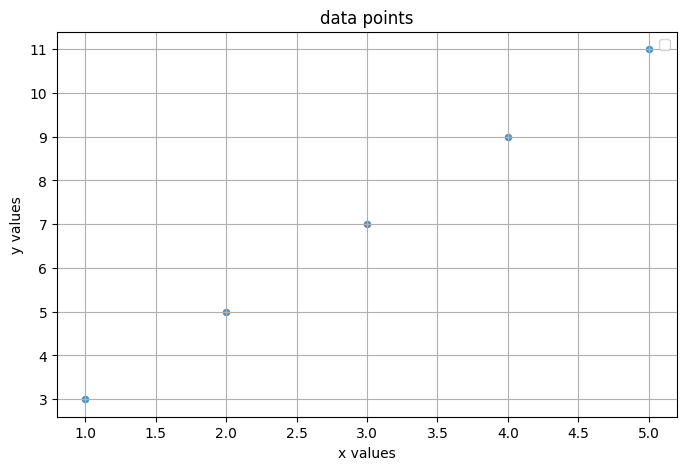

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(X, y, s=20, alpha=0.7)
plt.title("data points")
plt.xlabel("x values")
plt.ylabel("y values")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
w = np.random.randn(1, 1)
b = np.zeros((1, 1))

print(w)
print(b)

[[-0.94051294]]
[[0.]]


In [16]:
learning_rate = 0.01
epochs = 50

loss_history = []

for epoch in range(epochs):
    
    y_pred = np.dot(X, w) + b 
    loss = np.mean((y - y_pred) ** 2)
    loss_history.append(loss)
    dw = (-2 / len(X)) * np.dot(X.T, (y - y_pred)) 
    db = (-2 / len(X)) * np.sum(y - y_pred)   
    w -= learning_rate * dw
    b -= learning_rate * db

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}, w: {w[0][0]:.4f}, b: {b[0][0]:.4f}")

Epoch 2, Loss: 0.0060, w: 2.0364, b: 0.8379
Epoch 4, Loss: 0.0051, w: 2.0394, b: 0.8399
Epoch 6, Loss: 0.0047, w: 2.0410, b: 0.8415
Epoch 8, Loss: 0.0046, w: 2.0419, b: 0.8429
Epoch 10, Loss: 0.0045, w: 2.0422, b: 0.8441
Epoch 12, Loss: 0.0044, w: 2.0423, b: 0.8452
Epoch 14, Loss: 0.0043, w: 2.0422, b: 0.8463
Epoch 16, Loss: 0.0043, w: 2.0421, b: 0.8474
Epoch 18, Loss: 0.0042, w: 2.0419, b: 0.8485
Epoch 20, Loss: 0.0041, w: 2.0416, b: 0.8495
Epoch 22, Loss: 0.0041, w: 2.0414, b: 0.8505
Epoch 24, Loss: 0.0040, w: 2.0411, b: 0.8515
Epoch 26, Loss: 0.0040, w: 2.0408, b: 0.8525
Epoch 28, Loss: 0.0039, w: 2.0406, b: 0.8535
Epoch 30, Loss: 0.0039, w: 2.0403, b: 0.8545
Epoch 32, Loss: 0.0038, w: 2.0400, b: 0.8555
Epoch 34, Loss: 0.0038, w: 2.0397, b: 0.8565
Epoch 36, Loss: 0.0037, w: 2.0395, b: 0.8575
Epoch 38, Loss: 0.0037, w: 2.0392, b: 0.8584
Epoch 40, Loss: 0.0036, w: 2.0389, b: 0.8594
Epoch 42, Loss: 0.0036, w: 2.0387, b: 0.8603
Epoch 44, Loss: 0.0035, w: 2.0384, b: 0.8613
Epoch 46, Loss

In [17]:
y_final_pred = np.dot(X, w) + b
print("Final predictions:")
print(y_final_pred.flatten())

Final predictions:
[ 2.9017143   4.93936705  6.9770198   9.01467255 11.0523253 ]


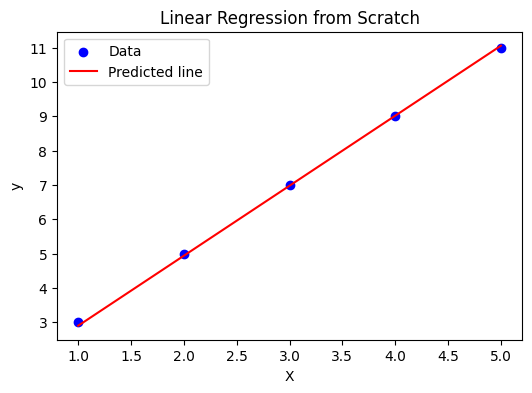

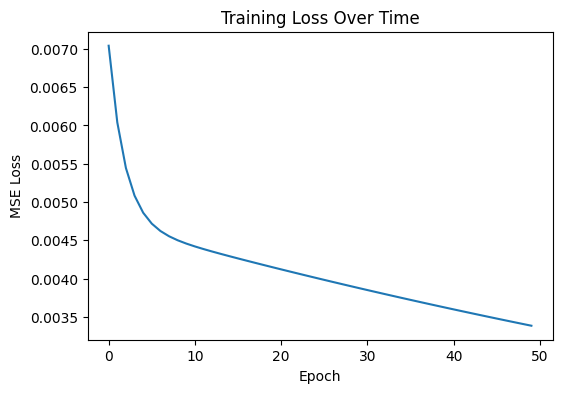

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(X, y, label="Data", color="blue")
plt.plot(X, y_final_pred, label="Predicted line", color="red")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression from Scratch")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Time")
plt.show()

# Sine wave prediction

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

x_train = np.linspace(-2*np.pi, 2*np.pi, 200)
y_train = np.sin(x_train)

x_train_tensor = torch.tensor(x_train, dtype=torch.float32).unsqueeze(1) 
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  

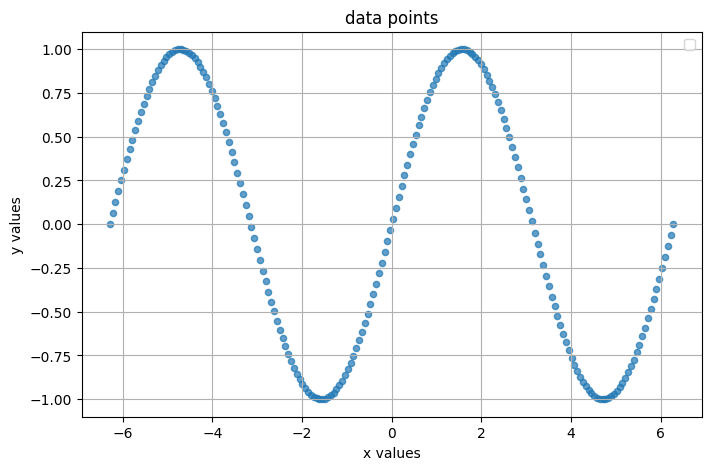

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(x_train_tensor, y_train_tensor, s=20, alpha=0.7)
plt.title("data points")
plt.xlabel("x values")
plt.ylabel("y values")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(1, 16)   
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 1)   
        self.act = nn.Tanh()          

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)
        return x

model = NeuralNetwork()
criterion = nn.MSELoss()               
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 2000
loss_history = []

for epoch in range(epochs):
    y_pred = model(x_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

Epoch 100/2000, Loss: 0.052374
Epoch 200/2000, Loss: 0.044751
Epoch 300/2000, Loss: 0.040973
Epoch 400/2000, Loss: 0.023825
Epoch 500/2000, Loss: 0.019033
Epoch 600/2000, Loss: 0.002079
Epoch 700/2000, Loss: 0.000090
Epoch 800/2000, Loss: 0.000028
Epoch 900/2000, Loss: 0.000015
Epoch 1000/2000, Loss: 0.000011
Epoch 1100/2000, Loss: 0.000010
Epoch 1200/2000, Loss: 0.000008
Epoch 1300/2000, Loss: 0.000056
Epoch 1400/2000, Loss: 0.000008
Epoch 1500/2000, Loss: 0.000007
Epoch 1600/2000, Loss: 0.000007
Epoch 1700/2000, Loss: 0.000008
Epoch 1800/2000, Loss: 0.000006
Epoch 1900/2000, Loss: 0.000006
Epoch 2000/2000, Loss: 0.000009


In [23]:
x_test = np.linspace(-2*np.pi, 2*np.pi, 400)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).unsqueeze(1)
y_test_pred = model(x_test_tensor).detach().numpy()

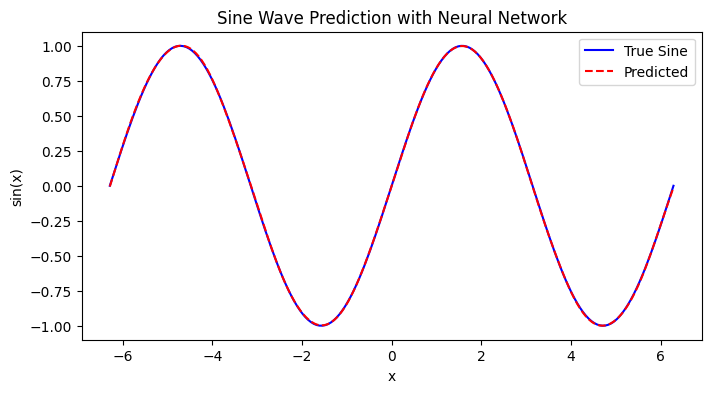

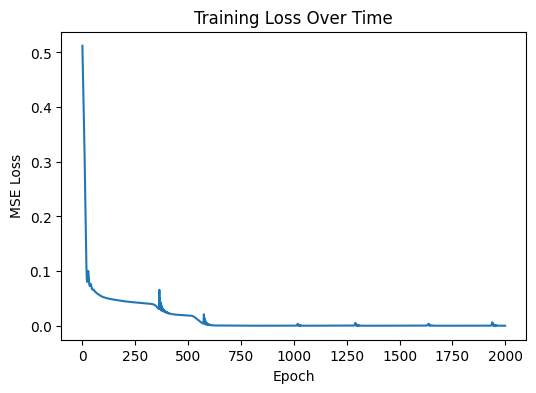

In [24]:
plt.figure(figsize=(8,4))
plt.plot(x_train, y_train, label="True Sine", color="blue")
plt.plot(x_test, y_test_pred, label="Predicted", color="red", linestyle="--")
plt.legend()
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Sine Wave Prediction with Neural Network")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Time")
plt.show()

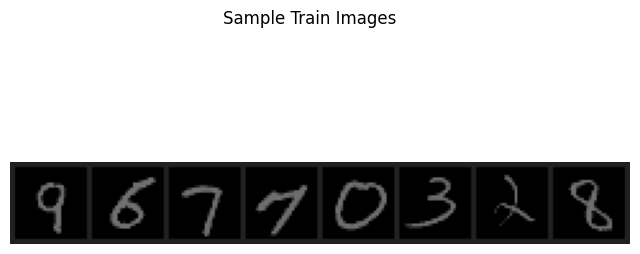

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize((0.5,), (0.5,)) 
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

def imshow(img):
    img = img * 0.3081 + 0.1307
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap="gray")
    plt.axis("off")

dataiter = iter(train_loader)
images, labels = next(dataiter)
plt.figure(figsize=(8, 4))
plt.suptitle("Sample Train Images")
imshow(torchvision.utils.make_grid(images[:8], nrow=8))
plt.show()

In [27]:
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        
        self.fc1 = nn.Linear(28*28, 256)   
        self.bn1 = nn.BatchNorm1d(256)    
        self.fc2 = nn.Linear(256, 128)    
        self.dropout = nn.Dropout(0.3)    
        self.fc3 = nn.Linear(128, 10)     
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)   
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MNISTNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

epochs = 5
train_losses = []

for epoch in range(epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()    
        loss.backward()          
        optimizer.step()         
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.3105
Epoch [2/5], Loss: 0.1255
Epoch [3/5], Loss: 0.0913
Epoch [4/5], Loss: 0.0738
Epoch [5/5], Loss: 0.0599


Test Accuracy: 97.93%


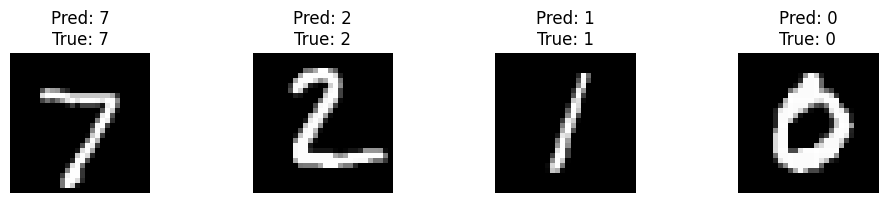

In [28]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

def imshow(img):
    img = img / 2 + 0.5  
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.axis('off')

dataiter = iter(test_loader)
images, labels = next(dataiter)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(2, 4, i+1)
    imshow(images[i])
    plt.title(f"Pred: {predicted[i].item()}\nTrue: {labels[i].item()}")
plt.show()